<a href="https://colab.research.google.com/github/specM7/DSGP_Group_33_Brain_Tumor_Predictor/blob/NoTumor-%26-Chatbot-Ahshaan-2506751/Notumor_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive to access dataset and save model
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Deep learning framework
import tensorflow as tf

# Image preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

# Model building
from tensorflow.keras import layers, models

# Training control
from tensorflow.keras.callbacks import EarlyStopping

# Evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Utilities
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# Define binary dataset base path
base_path = "/content/drive/MyDrive/NoTumor_Detection/Binary_Dataset"

# Training and testing folders
train_path = os.path.join(base_path, "Training")
test_path  = os.path.join(base_path, "Testing")

In [ ]:
# Data augmentation improves generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# Test generator (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 4480 images belonging to 2 classes.
Found 1120 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.


In [ ]:
# Load pretrained EfficientNetB0 for transfer learning
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
base_model.trainable = False

# Add binary classification head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Early stopping prevents overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 495s 3s/step - accuracy: 0.7345 - loss: 0.5858 - val_accuracy: 0.7500 - val_loss: 0.5604
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.7372 - loss: 0.5807 - val_accuracy: 0.7500 - val_loss: 0.5597
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.7467 - loss: 0.5670 - val_accuracy: 0.7500 - val_loss: 0.5595
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.7460 - loss: 0.5677 - val_accuracy: 0.7500 - val_loss: 0.5586
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 0.7452 - loss: 0.5673 - val_accuracy: 0.7500 - val_loss: 0.5572
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.7421 - loss: 0.5731 - val_accuracy: 0.7500 - val_loss: 0.5564
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.7502 - loss: 0.5639 - val_accuracy: 0.7500 - val_loss: 0.5564
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.7494 - loss: 0.5640 - val_accu

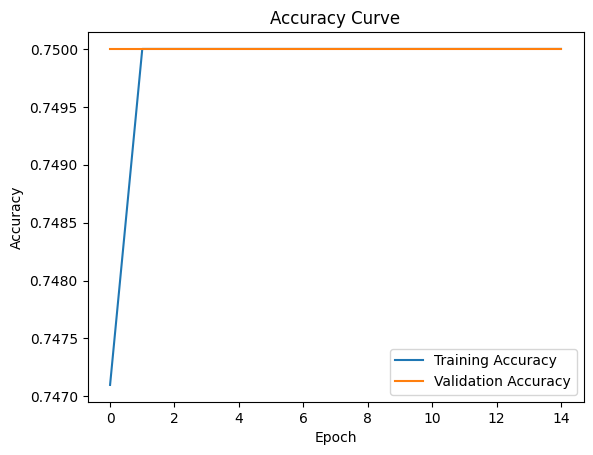

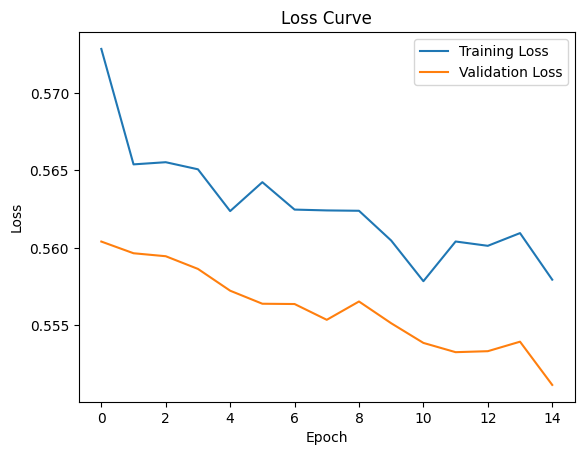

In [ ]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

In [ ]:
# Evaluate model on unseen test data
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 527s 11s/step - accuracy: 0.4176 - loss: 0.9105
Test Accuracy: 0.75
Test Loss: 0.5519965291023254


50/50 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step


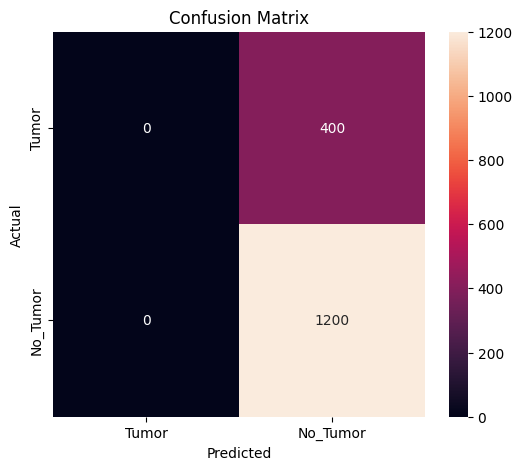

In [ ]:
# Predict test data
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes

# Generate confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Tumor","No_Tumor"],
            yticklabels=["Tumor","No_Tumor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
report = classification_report(true_classes, predicted_classes,
                               target_names=["Tumor","No_Tumor"])

print(report)

              precision    recall  f1-score   support

       Tumor       0.00      0.00      0.00       400
    No_Tumor       0.75      1.00      0.86      1200

    accuracy                           0.75      1600
   macro avg       0.38      0.50      0.43      1600
weighted avg       0.56      0.75      0.64      1600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


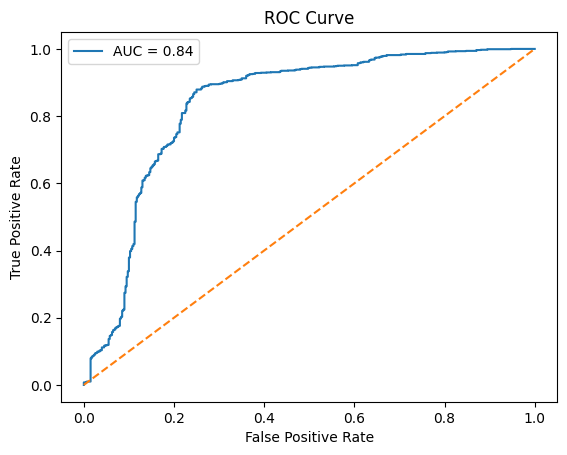

AUC Score: 0.8350697916666667


In [ ]:
# Get probability predictions
probs = predictions.flatten()

# Compute ROC
fpr, tpr, thresholds = roc_curve(true_classes, probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

In [ ]:
# Save trained binary model
model_path = "/content/drive/MyDrive/NoTumor_Detection/NoTumor_Binary_Model.h5"

model.save(model_path)

print("Binary model saved at:", model_path)

Binary model saved at: /content/drive/MyDrive/NoTumor_Detection/NoTumor_Binary_Model.h5


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Import TensorFlow
import tensorflow as tf

# Image preprocessing
from tensorflow.keras.preprocessing import image

# Utilities
import numpy as np
import os

In [ ]:
# Define saved model path
model_path = "/content/drive/MyDrive/NoTumor_Detection/NoTumor_Binary_Model.h5"

# Load model
model = tf.keras.models.load_model(model_path)

print("Model loaded successfully")

Model loaded successfully


In [ ]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
from google.colab import drive, files
import os

# Mount Drive
drive.mount('/content/drive')

# Load saved model
model_path = "/content/drive/MyDrive/NoTumor_Detection/NoTumor_Binary_Model.h5"
model = tf.keras.models.load_model(model_path)

print("Model loaded successfully")

# Upload MRI image
uploaded = files.upload()

# Automatically get uploaded file name
img_path = list(uploaded.keys())[0]

print("Uploaded Image:", img_path)

# Prediction function
def predict_mri(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array)[0][0]

    print("Raw Prediction Value:", prediction)

    if prediction > 0.5:
        print("Final Result: No Tumor Detected")
    else:
        print("Final Result: Tumor Detected")

# Run prediction
predict_mri(img_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Model loaded successfully
